In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from sklearn.datasets import load_iris

In [5]:
iris=load_iris()
iris.columns=iris.feature_names
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
print(df)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     species  
0          0

In [6]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='str')

In [7]:
x = df.drop('species', axis=1)
y = df['species']

In [8]:

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [10]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train_scaler,y_train)

y_pred=model.predict(x_test_scaler)



In [11]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy of DT:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy of DT: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [12]:
pred=model.predict([[5.1, 3.5, 1.4, 0.2]])
species = iris.target_names[pred[0]]
print(species)

virginica


In [13]:
print("Train:", model.score(x_train_scaler, y_train))
print("Test:", model.score(x_test_scaler, y_test))

Train: 1.0
Test: 1.0


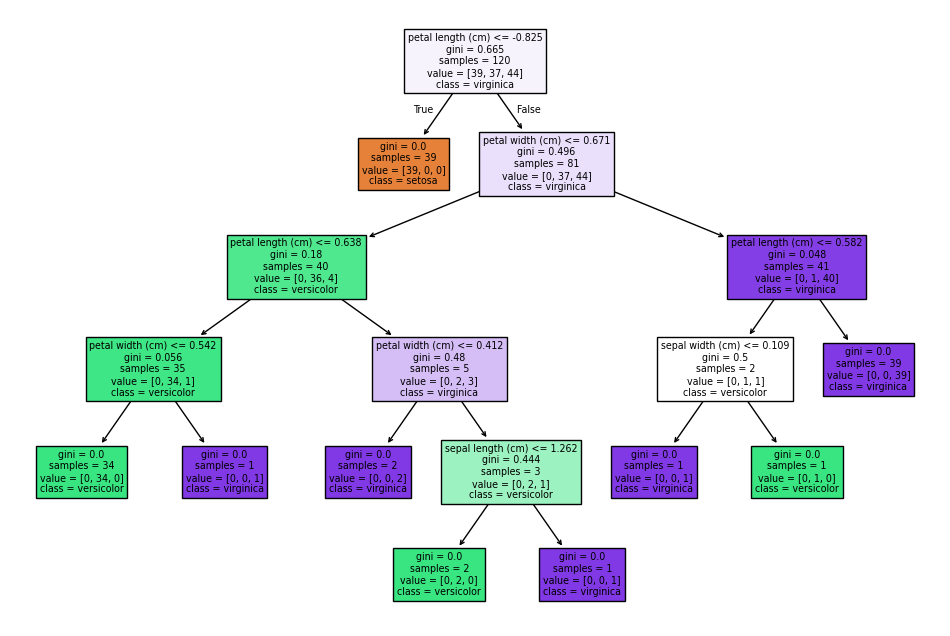

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, feature_names=x.columns, class_names=iris.target_names, filled=True)
plt.show()